In [2]:
import pandas as pd
import re
from urllib.parse import unquote
import ast

df = pd.read_json("urls.jsonl.gz", lines=True, nrows=5000000)
df

,display_id,urls
0,0o2M2ZebIqs,[http://www.youtube.com/watch?v=lepXEdv1Udc]
1,VPqJmODeZyk,"[https://goo.gl/JI78Ak, http://www.youtube.com..."
2,xLYGF-aCEHk,"[https://goo.gl/JI78Ak, http://www.youtube.com..."
3,TqzfdwSZdRc,"[https://goo.gl/JI78Ak, http://www.youtube.com..."
4,C-dn3p-ZTrM,"[https://goo.gl/JI78Ak, http://www.youtube.com..."
...,...,...
4999995,_wosLlvrAlk,"[https://youtu.be/dFV0-ODvkmg, https://youtu.b..."
4999996,ATwSpkqI2gk,"[https://youtu.be/hYsyxwrUl6E, https://youtu.b..."
4999997,SUhjSGXp3pI,"[https://youtu.be/udRqsEa2N9E, https://youtu.b..."
4999998,udRqsEa2N9E,"[https://youtu.be/USpa_aAP6sU, https://youtu.b..."


In [3]:
def extract_wiki_topics(url_list):
    topics = []
    for url in url_list:
        match = re.search(r'wikipedia\.org/wiki/([^#?]*)', url, re.IGNORECASE)
        if match:
            topic = match.group(1).replace('_', ' ').strip()
            # Skip empty or system pages
            if topic and topic.lower() not in ['main page', 'wikipedia', 'special', 'help']:
                topics.append(topic)
    return topics
# Apply the function
df['wiki_topics'] = df['urls'].apply(extract_wiki_topics)



# Remove rows with no Wikipedia links (optional)
df_wiki = df[df['wiki_topics'].apply(lambda x: len(x) > 0)]

# Flatten list of topics if you want one topic per row
df_flat = df_wiki.explode('wiki_topics').reset_index(drop=True)

print(df_flat)



KeyboardInterrupt: 

In [1]:
topic_counts = df_flat['wiki_topics'].value_counts().reset_index()

topic_counts.columns = ['topic', 'count']

topic_counts.head()
topic_counts.sort_values(by='count', ascending=False)

from rapidfuzz import fuzz

education_seeds = [
        
    # --- Natural Sciences ---
    "Physics", "Chemistry", "Biology", "Zoology", "Botany", "Genetics", "Microbiology",
    "Molecular Biology", "Neuroscience", "Biochemistry", "Ecology", "Astronomy", 
    "Astrophysics", "Geology", "Earth Science", "Environmental Science", "Meteorology", 
    "Oceanography", "Paleontology", "Geophysics",
    

    # --- Mathematics & Computing ---
    "Mathematics", "Statistics", "Probability", "Algebra", "Geometry", "Calculus",
    "Topology", "Number Theory", "Logic", "Data Science", "Machine Learning", 
    "Artificial Intelligence", "Computer Science", "Programming", "Algorithm", 
    "Software Engineering", "Information Theory", "Cryptography", "Computational Science",

    # --- Engineering & Technology ---
    "Engineering", "Mechanical Engineering", "Electrical Engineering", "Civil Engineering",
    "Chemical Engineering", "Aerospace Engineering", "Industrial Engineering", 
    "Biomedical Engineering", "Materials Science", "Nanotechnology", "Robotics", 
    "Systems Engineering", "Automation", "Control Theory", "Telecommunications", 
    "Structural Engineering", "Computer Engineering", "Energy Engineering", "Environmental Engineering",
    
    
    # --- Health & Medicine ---
    "Medicine", "Nursing", "Dentistry", "Pharmacy", "Public Health", "Epidemiology",
    "Anatomy", "Physiology", "Pathology", "Immunology", "Genomics", "Nutrition", 
    "Kinesiology", "Physical Therapy", "Neurosurgery", "Cardiology", "Psychiatry",
    "Oncology", "Dermatology", "Radiology",
    
    # --- Social Sciences ---
    "Sociology", "Psychology", "Political Science", "Economics", "Anthropology", 
    "Archaeology", "Human Geography", "Linguistics", "Demography", "International Relations", 
    "Cognitive Science", "Criminology", "Law", "Public Policy", "Gender Studies", 
    "Education", "Pedagogy", "Curriculum", "Instructional Design", "Educational Psychology",
    
    # --- Humanities ---
    "Philosophy", "History", "Literature", "Linguistics", "Art History", "Classics", 
    "Religious Studies", "Theology", "Ethics", "Aesthetics", "Logic", 
    "Cultural Studies", "Musicology", "Linguistics", "Philology",

    
    # --- Arts & Design ---
    "Fine Arts", "Visual Arts", "Music", "Performing Arts", "Film Studies", "Photography", 
    "Architecture", "Graphic Design", "Industrial Design", "Fashion Design", 
    "Interior Design", "Theatre", "Animation", "Digital Media", "Game Design",

    # --- Business & Management ---
    "Business", "Management", "Marketing", "Finance", "Accounting", 
    "Econometrics", "Entrepreneurship", "Operations Research", 
    "Supply Chain Management", "Human Resource Management", 
    "International Business", "Organizational Behavior",

    # --- Communication & Information ---
    "Communication", "Media Studies", "Journalism", "Library Science", 
    "Information Science", "Cultural Communication", "Public Relations", 
    "Digital Communication",

    # --- Environmental & Earth Studies ---
    "Environmental Studies", "Sustainability", "Ecology", "Conservation", 
    "Agriculture", "Forestry", "Climate Science", "Marine Biology", "Geography",
    
    # --- Education & Training ---
    "Education", "Teaching", "Learning", "Curriculum Development", 
    "Instructional Technology", "Distance Learning", "Special Education", 
    "Early Childhood Education", "Adult Education", "Higher Education", 
    "STEM Education", "Educational Research"
    
]



# 2️⃣ Function to detect education-related topics
def is_educational(topic, threshold=95):
    topic_lower = topic.lower()
    return any(fuzz.partial_ratio(topic_lower, seed.lower()) >= threshold for seed in education_seeds)

# 3️⃣ Apply filtering
topic_counts['is_educational'] = topic_counts['topic'].apply(is_educational)


df_edu = topic_counts[topic_counts['is_educational']].copy()

df_edu15 = df_edu.head(15)

df_edu15






NameError: name 'df_flat' is not defined

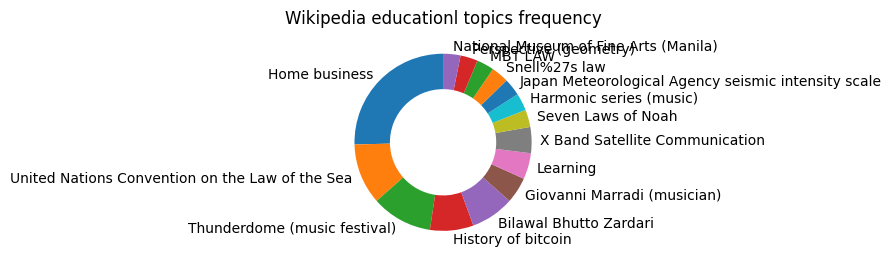

In [49]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
wedges, texts = plt.pie(
    df_edu15['count'],
    labels=df_edu15['topic'],
    startangle=90,
    wedgeprops=dict(width=0.4),  # Makes it a donut
    #autopct='%1.1f%%'
)

plt.title('Wikipedia educationl topics frequency')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Example: top 100 topics by frequency
# topic_counts_edu = df_edu['wiki_topics'].value_counts().reset_index()
# topic_counts_edu.columns = ['topic', 'count']

top_n = 20
topic_counts_top = df_edu.head(top_n)



# Create interactive pie chart
fig = px.pie(
    topic_counts_top,
    values='count',
    names='topic',
    #title='Top 15 Educational Wikipedia Topics',
    hole=0.3,  # donut style for a modern look
)

# Style adjustments
fig.update_traces(
    textposition='outside',
    textinfo='percent+label',
    pull=[0.03]*len(topic_counts_top),
)

# Remove legend and make layout clean
fig.update_layout(
    title_font=dict(size=22, family='Arial', color='black'),
    showlegend=False,  # <-- hides legend completely
    margin=dict(t=60, b=40, l=40, r=40)
)

# Save to HTML and show
fig.write_html("educational_topics_pie.html")



NameError: name 'site_counts_df' is not defined

Looking at wikipedia categories

In [46]:
import requests
import pandas as pd
from rapidfuzz import fuzz, process
import time

# Example educational keywords
edu_keywords = [
    "education", "school", "university", "college", "academic",
    "teaching", "learning", "science", "engineering", "mathematics",
    "physics", "chemistry", "biology", "research", "discipline", "subject", "field"
]

# Function to fetch categories for a list of Wikipedia titles
def get_wikipedia_categories(titles):
    BATCH_SIZE = 50
    categories_dict = {}
    for i in range(0, len(titles), BATCH_SIZE):
        batch = titles[i:i+BATCH_SIZE]
        titles_str = "|".join(batch)
        params = {
            "action": "query",
            "format": "json",
            "prop": "categories",
            "titles": titles_str,
            "cllimit": "max"
        }
        response = requests.get("https://en.wikipedia.org/w/api.php", params=params)
        data = response.json()
        pages = data.get("query", {}).get("pages", {})
        for page_id, page_data in pages.items():
            title = page_data.get("title")
            cats = [c["title"].lower() for c in page_data.get("categories", [])]
            categories_dict[title] = cats
        time.sleep(0.5)  # polite pause
    return categories_dict

# Function to check if categories contain educational keywords using RapidFuzz
def is_educational(categories, keywords=edu_keywords, threshold=70):
    if not categories:
        return False
    for cat in categories:
        match, score, _ = process.extractOne(cat, keywords, scorer=fuzz.partial_ratio)
        if score >= threshold:
            return True
    return False

# Suppose your DataFrame has a 'wiki_topics' column
titles = df['wiki_topics'].tolist()

# Fetch categories
categories_dict = get_wikipedia_categories(titles)

# Map categories to DataFrame
df['categories'] = df['wiki_topics'].map(categories_dict)

# Determine if educational
df['is_educational'] = df['categories'].apply(is_educational)

# Filter only educational topics
df_edu = df[df['is_educational']].copy()

# df_edu now contains only topics that are educational
print(df_edu.head())

TypeError: sequence item 0: expected str instance, list found

In [ ]:
Looking at other websites

In [ ]:
edu_domains = [
    r'wikipedia\.org',
    r'\.edu\b',
    r'\.ac\.[a-z]{2}\b',
    r'\.gov\b',
    r'researchgate\.net',
    r'arxiv\.org',
    r'nature\.com',
    r'sciencedirect\.com',
    r'springer\.com',
    r'elsevier\.com',
    r'jstor\.org',
    r'cambridge\.org',
    r'oxfordjournals\.org',
    r'pnas\.org',
    r'nih\.gov',
    r'nasa\.gov',
    r'plos\.org',
    r'biorxiv\.org',
    r'medrxiv\.org'
]

# Combine into regex
edu_pattern = re.compile('|'.join(edu_domains), re.IGNORECASE)

# Filter DataFrame by whether the URL matches any educational/scientific site
df['is_scholarly'] = df['urls'].apply(lambda urls: any(re.search(edu_pattern, str(u)) for u in urls) if isinstance(urls, list) else re.search(edu_pattern, str(urls)))

# Combine with educational-topic filtering if you already have 'is_educational'
df['is_edu_or_scholarly'] = df['is_educational'] | df['is_scholarly']

# Filter to keep only relevant rows
df_edu_all = df[df['is_edu_or_scholarly']].copy()

# Optional: reset index and inspect
df_edu_all.reset_index(drop=True, inplace=True)
print(df_edu_all.head())
